# Campus Walk — Midstance Entropy + GPS Map

Runs the full midstance entropy pipeline on a single multi-surface campus walk
(`Kristian_dry_0425.csv`) and overlays the per-step results on the recorded GPS
route (`activity_22645980458.gpx`).

### What the notebook produces
| Output | Description |
|---|---|
| `campus_entropy_scores.csv` | Per-step: evenness, unevenness, H, CV, GPS coords |
| `campus_walk_map.html` | Folium map — coloured route + per-step markers |
| `campus_walk_detail_map.html` | Same map with a richer popup and right/left foot toggle |

### Two metrics per step
| Metric | Formula | Interpretation |
|---|---|---|
| **evenness_score** | H_spatial / log₂(12) | 0–1; 1 = all 12 sensors equally loaded |
| **unevenness_score** | 1 − evenness | 0–1; 1 = load concentrated in one zone |
| **H_spatial** | Shannon entropy (bits) | Raw; max = log₂(12) ≈ 3.585 |
| **cv_spatial** | σ / μ across sensors | Coefficient of variation; higher = more uneven |

### GPS–Insole time alignment
Both streams share the same Unix-epoch-millisecond clock.  
Each step's mid-stance centre timestamp is nearest-neighbour matched to the GPX track.

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.stats import entropy as scipy_entropy
import xml.etree.ElementTree as ET
import folium
from folium.plugins import MarkerCluster
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

print('✓ Libraries loaded')
print(f'  folium {folium.__version__}')

✓ Libraries loaded
  folium 0.20.0


## Cell 2 — Configuration

In [2]:
# ── File paths ─────────────────────────────────────────────────────────────────
CSV_PATH = 'Kristian_dry_0425.csv'
GPX_PATH = 'activity_22645980458.gpx'

# ── Sensor columns ─────────────────────────────────────────────────────────────
PRESSURE_COLS    = [f'pressure_{i:02d}' for i in range(1, 13)]
FOREFOOT_SENSORS = ['pressure_01','pressure_02','pressure_05',
                    'pressure_06','pressure_09','pressure_12']
MIDFOOT_SENSORS  = ['pressure_03','pressure_04','pressure_07']
HINDFOOT_SENSORS = ['pressure_08','pressure_10','pressure_11']

# ── Recording parameters ───────────────────────────────────────────────────────
SAMPLE_RATE_MS    = 4           # 4 ms / sample
MAX_ENTROPY       = np.log2(12) # ≈ 3.585 bits — perfect uniform distribution

# ── Stance detection ───────────────────────────────────────────────────────────
STANCE_PERCENTILE = 15   # samples >= p15 of recording → in stance
MIN_STANCE_SAMP   = 20   # ≈  80 ms minimum stance duration
MAX_STANCE_SAMP   = 500  # ≈ 2000 ms maximum

# ── Mid-stance window ──────────────────────────────────────────────────────────
MS_START = 1/3   # 33% into stance
MS_END   = 2/3   # 67% into stance

# ── Aesthetics ─────────────────────────────────────────────────────────────────
FOOT_COLORS = {'RIGHT': '#4C72B0', 'LEFT': '#C44E52'}

print('Configuration ready.')
print(f'  Max entropy (12 sensors): {MAX_ENTROPY:.4f} bits')
print(f'  Mid-stance window: {MS_START:.0%}–{MS_END:.0%} of stance duration')

Configuration ready.
  Max entropy (12 sensors): 3.5850 bits
  Mid-stance window: 33%–67% of stance duration


## Cell 3 — Load & Clean Insole Data

In [3]:
raw = pd.read_csv(CSV_PATH, low_memory=False)
before = len(raw)
raw = raw[raw['corrupt'] == 0].copy()
raw['total_pressure'] = raw[PRESSURE_COLS].sum(axis=1)

duration_s = (raw['timestamp'].max() - raw['timestamp'].min()) / 1000
print(f'Insole data: {len(raw):,} rows  ({before - len(raw)} corrupt removed)')
print(f'  Feet detected : {sorted(raw["sole_id"].unique())}  (1=RIGHT, 2=LEFT)')
print(f'  Duration      : {duration_s:.1f} s  ({duration_s/60:.2f} min)')
print(f'  Pressure range: {raw["total_pressure"].min():.0f} – {raw["total_pressure"].max():.0f}')

Insole data: 51,267 rows  (0 corrupt removed)
  Feet detected : [np.int64(1), np.int64(2)]  (1=RIGHT, 2=LEFT)
  Duration      : 410.1 s  (6.84 min)
  Pressure range: 2516 – 4969


## Cell 4 — Load & Parse GPX Track

In [4]:
def parse_gpx(path):
    """
    Parse a GPX file and return a DataFrame with columns:
      lat, lon, unix_ms, dt
    unix_ms is the Unix epoch timestamp in milliseconds — same unit
    as the insole CSV 'timestamp' column, so they can be joined directly.
    """
    tree = ET.parse(path)
    root = tree.getroot()
    ns   = {'gpx': 'http://www.topografix.com/GPX/1/1'}

    rows = []
    for trkpt in root.findall('.//gpx:trkpt', ns):
        lat  = float(trkpt.get('lat'))
        lon  = float(trkpt.get('lon'))
        t_el = trkpt.find('gpx:time', ns)
        dt   = pd.to_datetime(t_el.text.strip(), utc=True)
        rows.append({
            'lat'     : lat,
            'lon'     : lon,
            'dt'      : dt,
            'unix_ms' : int(dt.value // 1_000_000),   # nanoseconds → ms
        })

    return pd.DataFrame(rows)


gpx_df = parse_gpx(GPX_PATH)
gpx_duration = (gpx_df['unix_ms'].max() - gpx_df['unix_ms'].min()) / 1000

print(f'GPX track: {len(gpx_df)} points')
print(f'  Start : {gpx_df["dt"].iloc[0]}')
print(f'  End   : {gpx_df["dt"].iloc[-1]}')
print(f'  Duration: {gpx_duration:.1f} s  ({gpx_duration/60:.2f} min)')
print(f'  Bounding box: lat {gpx_df["lat"].min():.5f}–{gpx_df["lat"].max():.5f}, '
      f'lon {gpx_df["lon"].min():.5f}–{gpx_df["lon"].max():.5f}')

GPX track: 440 points
  Start : 2026-04-24 19:09:08+00:00
  End   : 2026-04-24 19:16:27+00:00
  Duration: 439.0 s  (7.32 min)
  Bounding box: lat 42.33698–42.34058, lon -71.09356–-71.09060


## Cell 5 — Timestamp Alignment Check

Both streams use Unix epoch milliseconds.  
A visual sanity-check confirms they overlap in time.

=== Timestamp alignment ===
Insole : 2026-04-24 19:09:06.944000+00:00  →  2026-04-24 19:15:57.072000+00:00
GPX    : 2026-04-24 19:09:08+00:00  →  2026-04-24 19:16:27+00:00
Overlap: 409.1 s  →  ✓ OK


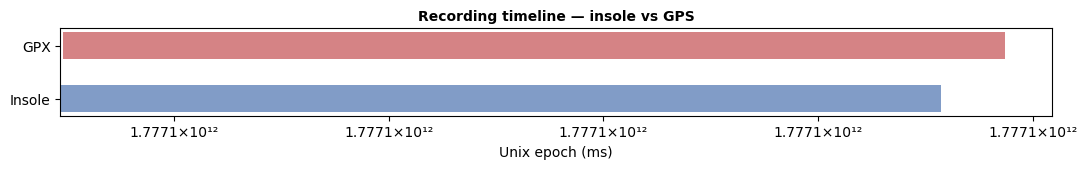

In [5]:
insole_start_ms = raw['timestamp'].min()
insole_end_ms   = raw['timestamp'].max()
gpx_start_ms    = gpx_df['unix_ms'].min()
gpx_end_ms      = gpx_df['unix_ms'].max()

overlap_start = max(insole_start_ms, gpx_start_ms)
overlap_end   = min(insole_end_ms,   gpx_end_ms)
overlap_s     = (overlap_end - overlap_start) / 1000

print('=== Timestamp alignment ===')
print(f'Insole : {pd.to_datetime(insole_start_ms, unit="ms", utc=True)}  →  '
      f'{pd.to_datetime(insole_end_ms, unit="ms", utc=True)}')
print(f'GPX    : {pd.to_datetime(gpx_start_ms,    unit="ms", utc=True)}  →  '
      f'{pd.to_datetime(gpx_end_ms,   unit="ms", utc=True)}')
print(f'Overlap: {overlap_s:.1f} s  →  {"✓ OK" if overlap_s > 0 else "✗ NO OVERLAP"}')

# Timeline bar chart
fig, ax = plt.subplots(figsize=(11, 1.8))
for label, (s, e), color in [
    ('Insole', (insole_start_ms, insole_end_ms), '#4C72B0'),
    ('GPX',   (gpx_start_ms,    gpx_end_ms),    '#C44E52'),
]:
    ax.barh(label, e - s, left=s, height=0.5, color=color, alpha=0.7)
ax.set_xlabel('Unix epoch (ms)')
ax.set_title('Recording timeline — insole vs GPS', fontsize=10, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e12:.4f}×10¹²'))
plt.tight_layout()
plt.savefig('timeline_check.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 6 — Stance Phase Detection

In [6]:
def detect_stance_windows(sdf,
                           stance_pct = STANCE_PERCENTILE,
                           min_samp   = MIN_STANCE_SAMP,
                           max_samp   = MAX_STANCE_SAMP):
    """
    Detect stance windows from a single-sole DataFrame.
    Samples with total_pressure >= p{stance_pct} are classed as 'in stance'.
    Consecutive in-stance runs are kept if their duration is plausible for gait.
    Returns (windows, adaptive_threshold).
    """
    sig       = sdf['total_pressure'].values
    threshold = np.percentile(sig, stance_pct)
    in_stance = sig >= threshold

    windows, i = [], 0
    while i < len(in_stance):
        if in_stance[i]:
            start = i
            while i < len(in_stance) and in_stance[i]:
                i += 1
            dur = i - start
            if min_samp <= dur <= max_samp:
                windows.append({'start': start, 'end': i, 'duration': dur})
        else:
            i += 1
    return windows, threshold


stance_data = {}   # sole_id → (sdf_sorted, windows, threshold)
for sole_id in sorted(raw['sole_id'].unique()):
    sdf  = raw[raw['sole_id'] == sole_id].sort_values('timestamp').reset_index(drop=True)
    wins, thr = detect_stance_windows(sdf)
    stance_data[sole_id] = (sdf, wins, thr)
    foot = 'RIGHT' if sole_id == 1 else 'LEFT'
    durs = [w['duration'] for w in wins]
    print(f'{foot} (sole_id={sole_id}): {len(wins):>4} stances detected  '
          f'threshold={thr:.0f}  '
          f'mean={np.mean(durs):.0f} samp = {np.mean(durs)*SAMPLE_RATE_MS:.0f} ms')

RIGHT (sole_id=1):  340 stances detected  threshold=2801  mean=58 samp = 233 ms
LEFT (sole_id=2):  290 stances detected  threshold=3096  mean=67 samp = 267 ms


## Cell 7 — Midstance Entropy Feature Extraction

For each stance window:
1. Slice the middle third (33%–67%) → **mid-stance window**
2. Average all 12 pressure channels across the slice → `mp[12]`
3. Normalise → probability distribution → **Shannon entropy H_spatial**
4. Derive **evenness** = H / log₂(12) and **unevenness** = 1 − evenness
5. Record the mid-stance centre **timestamp** for GPS matching

In [7]:
def compute_midstance_features(sdf, wins, sole_id,
                                ms_start=MS_START, ms_end=MS_END):
    """
    Extract per-step mid-stance evenness features.

    Returns a DataFrame with one row per step:
      step_idx, sole_id, foot, stance_dur_ms,
      H_spatial, cv_spatial, evenness_score, unevenness_score,
      total_pressure_ms, ms_centre_ts,
      forefoot_pct, midfoot_pct, hindfoot_pct,
      mean_pressure_01 … mean_pressure_12
    """
    foot    = 'RIGHT' if sole_id == 1 else 'LEFT'
    records = []

    for step_idx, win in enumerate(wins):
        s, e, d = win['start'], win['end'], win['duration']
        ms_s = s + int(d * ms_start)
        ms_e = s + int(d * ms_end)
        if ms_e <= ms_s:
            continue

        ms_slice = sdf.iloc[ms_s:ms_e]
        mp       = ms_slice[PRESSURE_COLS].mean().values.astype(float)
        total    = mp.sum()
        if total < 10:
            continue

        # ── Entropy & scores ─────────────────────────────────────────────────
        p_norm         = np.clip(mp / total, 1e-10, 1.0)
        H_spatial      = scipy_entropy(p_norm, base=2)
        cv_spatial     = mp.std() / (mp.mean() + 1e-10)
        evenness_score   = H_spatial / MAX_ENTROPY
        unevenness_score = 1.0 - evenness_score

        # ── Zone contributions (relative to uniform) ──────────────────────────
        uniform_mean = total / len(PRESSURE_COLS)
        fore_idx = [PRESSURE_COLS.index(c) for c in FOREFOOT_SENSORS if c in PRESSURE_COLS]
        mid_idx  = [PRESSURE_COLS.index(c) for c in MIDFOOT_SENSORS  if c in PRESSURE_COLS]
        hind_idx = [PRESSURE_COLS.index(c) for c in HINDFOOT_SENSORS if c in PRESSURE_COLS]
        forefoot_pct = 100 * mp[fore_idx].mean() / (uniform_mean + 1e-10)
        midfoot_pct  = 100 * mp[mid_idx].mean()  / (uniform_mean + 1e-10)
        hindfoot_pct = 100 * mp[hind_idx].mean() / (uniform_mean + 1e-10)

        # ── Mid-stance centre timestamp (for GPS matching) ────────────────────
        centre_ts = int(sdf.iloc[(ms_s + ms_e) // 2]['timestamp'])

        records.append({
            'step_idx'         : step_idx,
            'sole_id'          : sole_id,
            'foot'             : foot,
            'stance_dur_ms'    : d * SAMPLE_RATE_MS,
            'H_spatial'        : H_spatial,
            'cv_spatial'       : cv_spatial,
            'evenness_score'   : evenness_score,
            'unevenness_score' : unevenness_score,
            'total_pressure_ms': total,
            'ms_centre_ts'     : centre_ts,
            'forefoot_pct'     : forefoot_pct,
            'midfoot_pct'      : midfoot_pct,
            'hindfoot_pct'     : hindfoot_pct,
            **{f'mean_{col}': float(v) for col, v in zip(PRESSURE_COLS, mp)}
        })

    return pd.DataFrame(records)


all_rows = []
for sole_id, (sdf, wins, _) in stance_data.items():
    feat = compute_midstance_features(sdf, wins, sole_id)
    all_rows.append(feat)
    foot = 'RIGHT' if sole_id == 1 else 'LEFT'
    print(f'{foot}: {len(feat):>4} steps extracted  '
          f'evenness={feat["evenness_score"].mean():.4f}±{feat["evenness_score"].std():.4f}  '
          f'H={feat["H_spatial"].mean():.4f} bits')

features = pd.concat(all_rows, ignore_index=True)
print(f'\nTotal steps: {len(features)}')

RIGHT:  340 steps extracted  evenness=0.9875±0.0043  H=3.5401 bits
LEFT:  290 steps extracted  evenness=0.9906±0.0023  H=3.5512 bits

Total steps: 630


## Cell 8 — GPS Matching

Each step's `ms_centre_ts` (Unix ms) is matched to the nearest GPX point using
a **sorted merge-asof** so no looping is needed and there are no duplicate GPS
assignments.  Steps outside the GPS recording window are flagged and kept but
excluded from the map.

In [8]:
# Sort both by timestamp before merge_asof
feat_sorted = features.sort_values('ms_centre_ts').reset_index(drop=True)
gpx_sorted  = gpx_df.sort_values('unix_ms').reset_index(drop=True)

# Nearest-neighbour match (backward = nearest GPX point at or before step ts)
matched = pd.merge_asof(
    feat_sorted,
    gpx_sorted[['unix_ms','lat','lon']].rename(columns={'unix_ms': 'ms_centre_ts'}),
    on='ms_centre_ts',
    direction='nearest',
    tolerance=5000,   # within 5 s — steps outside GPS window get NaN coords
)

matched_ok  = matched.dropna(subset=['lat','lon'])
matched_bad = matched[matched['lat'].isna()]

print(f'Steps matched to GPS : {len(matched_ok)}')
print(f'Steps outside GPS window (no coords): {len(matched_bad)}')
print(f'GPS match time tolerance : 5 s')

# Restore original step order for further analysis
features = matched.sort_values(['sole_id','step_idx']).reset_index(drop=True)

Steps matched to GPS : 630
Steps outside GPS window (no coords): 0
GPS match time tolerance : 5 s


## Cell 9 — Summary Statistics

In [9]:
agg = (
    features
    .groupby('foot')
    .agg(
        n_steps          = ('H_spatial',         'count'),
        mean_H           = ('H_spatial',         'mean'),
        std_H            = ('H_spatial',         'std'),
        mean_evenness    = ('evenness_score',    'mean'),
        std_evenness     = ('evenness_score',    'std'),
        mean_unevenness  = ('unevenness_score',  'mean'),
        std_unevenness   = ('unevenness_score',  'std'),
        mean_CV          = ('cv_spatial',        'mean'),
        mean_stance_ms   = ('stance_dur_ms',     'mean'),
    )
    .round(5)
)

print('=== Per-Foot Summary ===')
try:
    display(agg)
except NameError:
    print(agg.to_string())

=== Per-Foot Summary ===


,n_steps,mean_H,std_H,mean_evenness,std_evenness,mean_unevenness,std_unevenness,mean_CV,mean_stance_ms
foot,,,,,,,,,
LEFT,290,3.55121,0.00824,0.99059,0.00230,0.00941,0.00230,0.21552,266.53793
RIGHT,340,3.54011,0.01535,0.98749,0.00428,0.01251,0.00428,0.24441,233.28235


## Cell 10 — Visualisation: Evenness Over Time

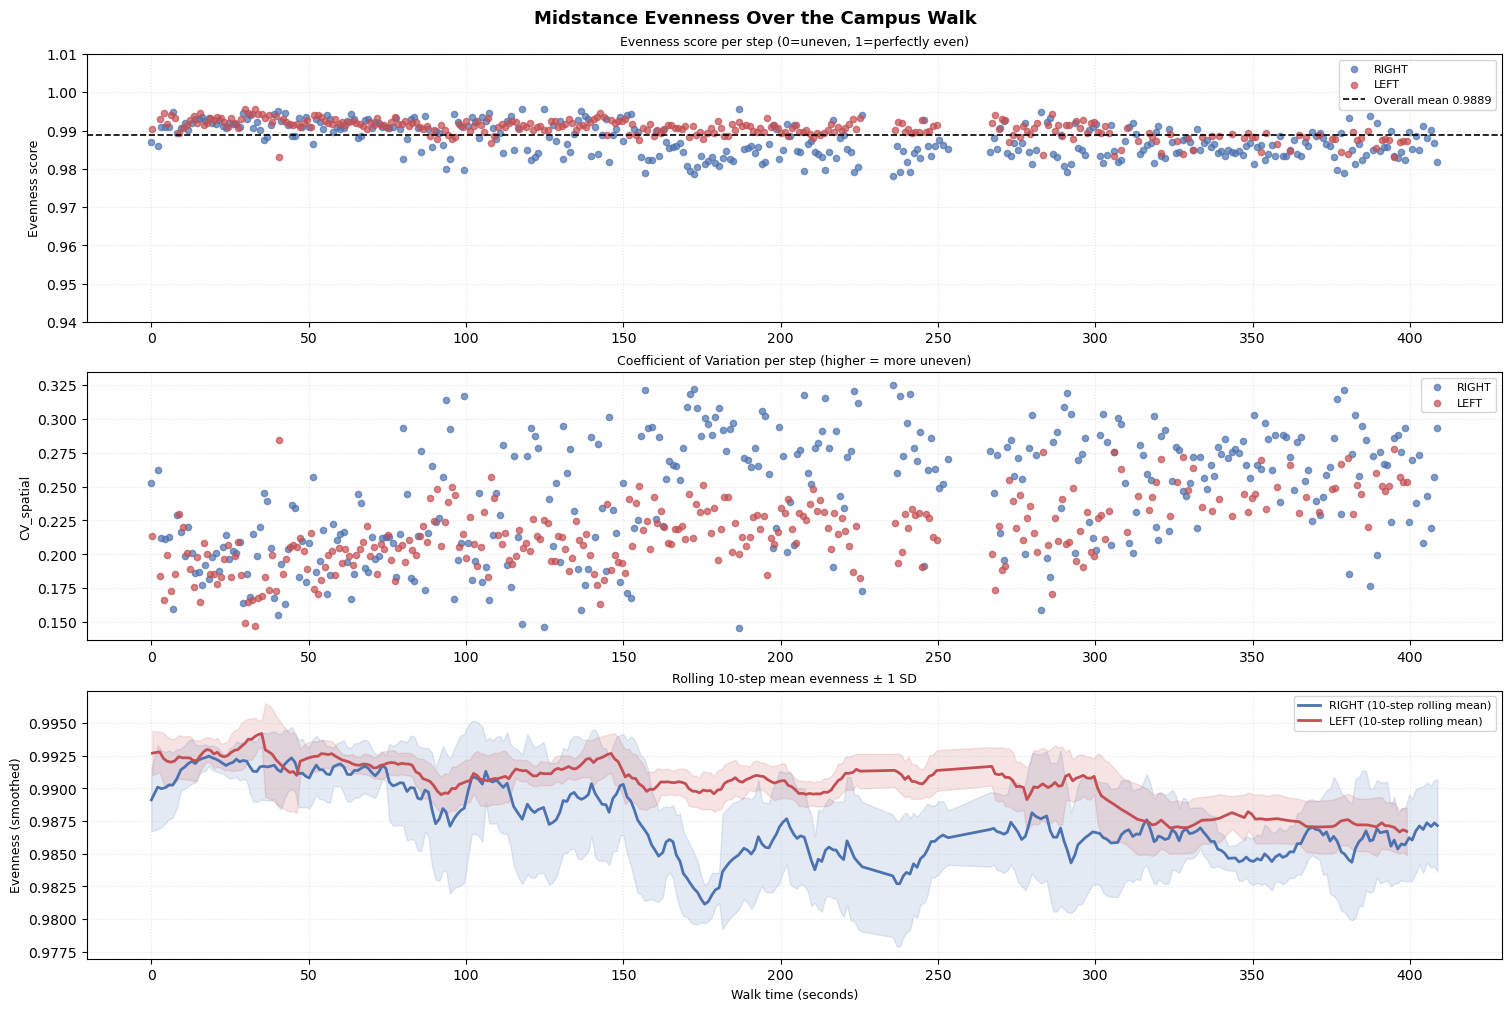

Saved → evenness_over_time.png


In [10]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), constrained_layout=True)
fig.suptitle('Midstance Evenness Over the Campus Walk', fontsize=13, fontweight='bold')

# Relative walk time (seconds from first step)
features['walk_time_s'] = (features['ms_centre_ts'] - features['ms_centre_ts'].min()) / 1000

for foot, color in FOOT_COLORS.items():
    fd = features[features['foot'] == foot]
    axes[0].scatter(fd['walk_time_s'], fd['evenness_score'],
                    c=color, label=foot, s=20, alpha=0.7)

axes[0].axhline(features['evenness_score'].mean(), color='black', ls='--', lw=1.2,
                label=f'Overall mean {features["evenness_score"].mean():.4f}')
axes[0].set_ylabel('Evenness score', fontsize=9)
axes[0].set_ylim(0.94, 1.01)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, ls=':')
axes[0].set_title('Evenness score per step (0=uneven, 1=perfectly even)', fontsize=9)

for foot, color in FOOT_COLORS.items():
    fd = features[features['foot'] == foot]
    axes[1].scatter(fd['walk_time_s'], fd['cv_spatial'],
                    c=color, label=foot, s=20, alpha=0.7)

axes[1].set_ylabel('CV_spatial', fontsize=9)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, ls=':')
axes[1].set_title('Coefficient of Variation per step (higher = more uneven)', fontsize=9)

# Rolling 10-step smoothed evenness per foot
for foot, color in FOOT_COLORS.items():
    fd = features[features['foot'] == foot].sort_values('walk_time_s')
    rolled = fd['evenness_score'].rolling(10, center=True, min_periods=3).mean()
    axes[2].plot(fd['walk_time_s'], rolled, color=color, lw=2, label=f'{foot} (10-step rolling mean)')
    axes[2].fill_between(fd['walk_time_s'],
                         fd['evenness_score'].rolling(10, center=True, min_periods=3).mean()
                         - fd['evenness_score'].rolling(10, center=True, min_periods=3).std(),
                         fd['evenness_score'].rolling(10, center=True, min_periods=3).mean()
                         + fd['evenness_score'].rolling(10, center=True, min_periods=3).std(),
                         alpha=0.15, color=color)

axes[2].set_xlabel('Walk time (seconds)', fontsize=9)
axes[2].set_ylabel('Evenness (smoothed)', fontsize=9)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, ls=':')
axes[2].set_title('Rolling 10-step mean evenness ± 1 SD', fontsize=9)

plt.savefig('evenness_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → evenness_over_time.png')

## Cell 11 — Visualisation: Box Plot + Sensor Heatmap

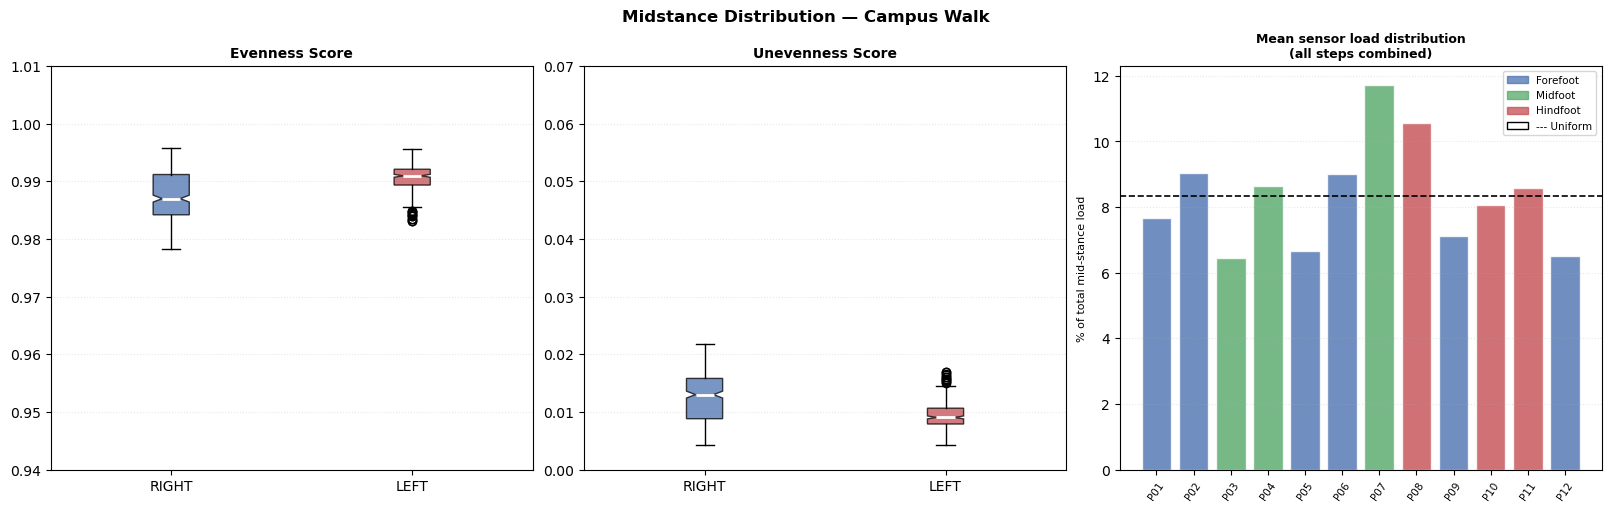

Saved → evenness_distribution.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('Midstance Distribution — Campus Walk', fontsize=12, fontweight='bold')

# ── Box plots ─────────────────────────────────────────────────────────────────
for ax, metric, title, ylim in [
    (axes[0], 'evenness_score',   'Evenness Score',   (0.94, 1.01)),
    (axes[1], 'unevenness_score', 'Unevenness Score', (0.0,  0.07)),
]:
    groups = [features[features['foot'] == f][metric].values for f in ['RIGHT','LEFT']]
    bp = ax.boxplot(groups, patch_artist=True, notch=True,
                    medianprops=dict(color='white', linewidth=2))
    for patch, foot in zip(bp['boxes'], ['RIGHT','LEFT']):
        patch.set_facecolor(FOOT_COLORS[foot])
        patch.set_alpha(0.75)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['RIGHT', 'LEFT'])
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.3, axis='y', ls=':')

# ── Mean sensor contribution heatmap (both feet combined) ────────────────────
mean_cols  = [f'mean_pressure_{i:02d}' for i in range(1, 13)]
mean_cols_present = [c for c in mean_cols if c in features.columns]
avg_mp     = features[mean_cols_present].mean().values
pct_mp     = 100 * avg_mp / avg_mp.sum()

zone_map   = {}
for c in FOREFOOT_SENSORS: zone_map[c] = '#4C72B0'
for c in MIDFOOT_SENSORS:  zone_map[c] = '#55A868'
for c in HINDFOOT_SENSORS: zone_map[c] = '#C44E52'
bar_colors = [zone_map.get(f'pressure_{i:02d}', '#999') for i in range(1, 13)]

ax = axes[2]
ax.bar(range(1, 13), pct_mp, color=bar_colors, alpha=0.8, edgecolor='white')
ax.axhline(100/12, color='black', ls='--', lw=1.2, label=f'Uniform ({100/12:.2f}%)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels([f'P{i:02d}' for i in range(1, 13)], rotation=55, fontsize=7.5)
ax.set_ylabel('% of total mid-stance load', fontsize=8)
ax.set_title('Mean sensor load distribution\n(all steps combined)', fontsize=9, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y', ls=':')
patches = [mpatches.Patch(color=c, label=z, alpha=0.75)
           for z, c in [('Forefoot','#4C72B0'),('Midfoot','#55A868'),('Hindfoot','#C44E52')]]
ax.legend(handles=patches + [mpatches.Patch(color='white', label='--- Uniform', ec='black')],
          fontsize=7.5, loc='upper right')

plt.savefig('evenness_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → evenness_distribution.png')

## Cell 12 — Export Enriched CSV

In [12]:
export_cols = [
    'sole_id', 'foot', 'step_idx',
    'stance_dur_ms', 'walk_time_s',
    'H_spatial', 'cv_spatial',
    'evenness_score', 'unevenness_score',
    'total_pressure_ms',
    'forefoot_pct', 'midfoot_pct', 'hindfoot_pct',
    'ms_centre_ts', 'lat', 'lon',
]

export_df = features[[c for c in export_cols if c in features.columns]].copy()
export_df.to_csv('campus_entropy_scores.csv', index=False)
print(f'✓ Saved → campus_entropy_scores.csv  ({export_df.shape[0]} rows × {export_df.shape[1]} cols)')
try:
    display(export_df.head(6))
except NameError:
    print(export_df.head(6).to_string())

✓ Saved → campus_entropy_scores.csv  (630 rows × 16 cols)


,sole_id,foot,step_idx,stance_dur_ms,walk_time_s,H_spatial,cv_spatial,evenness_score,unevenness_score,total_pressure_ms,forefoot_pct,midfoot_pct,hindfoot_pct,ms_centre_ts,lat,lon
0,1,RIGHT,0,560,0.000,3.538249,0.252661,0.986970,0.013030,3900.957447,84.810603,113.451689,116.927105,1777057748048,42.336990,-71.090600
1,1,RIGHT,1,224,2.016,3.534972,0.262139,0.986055,0.013945,4107.789474,82.969455,109.342968,124.718122,1777057750064,42.336983,-71.090596
2,1,RIGHT,2,228,3.200,3.552007,0.211775,0.990807,0.009193,4126.789474,89.923351,106.982617,113.170682,1777057751248,42.336983,-71.090606
3,1,RIGHT,3,184,4.448,3.552444,0.211260,0.990929,0.009071,4044.200000,88.122909,109.984669,113.769514,1777057752496,42.336989,-71.090607
4,1,RIGHT,4,180,5.616,3.552049,0.213101,0.990819,0.009181,4009.800000,88.144047,109.804313,113.907593,1777057753664,42.336998,-71.090630
5,1,RIGHT,5,196,6.800,3.566924,0.159942,0.994968,0.005032,4105.250000,93.362158,110.273430,103.002253,1777057754848,42.337002,-71.090650


## Cell 13 — Folium Map: GPS Route Coloured by Evenness

The GPX track is drawn as a **polyline coloured by the running-average evenness** of nearby steps.  
Each matched step also gets a small **circle marker** coloured on the same Red→Green scale.

- 🟢 Green = high evenness (balanced load across all 12 sensors)
- 🔴 Red   = low evenness (load concentrated in fewer sensors)
- Click any marker for the full per-step stats popup.

In [13]:
def score_to_hex(score, vmin=None, vmax=None):
    """Map an evenness score to a hex colour via RdYlGn colormap."""
    if vmin is None: vmin = features['evenness_score'].quantile(0.05)
    if vmax is None: vmax = features['evenness_score'].quantile(0.95)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    rgba = cm.RdYlGn(norm(np.clip(score, vmin, vmax)))
    return mcolors.to_hex(rgba)


ev_min = features['evenness_score'].quantile(0.05)
ev_max = features['evenness_score'].quantile(0.95)

centre_lat = gpx_df['lat'].mean()
centre_lon = gpx_df['lon'].mean()

m = folium.Map(
    location=[centre_lat, centre_lon],
    zoom_start=17,
    tiles='CartoDB positron',
)

# ── Full GPS polyline (neutral grey background) ───────────────────────────────
route_coords = list(zip(gpx_df['lat'], gpx_df['lon']))
folium.PolyLine(
    route_coords,
    color='#aaaaaa', weight=3, opacity=0.5,
    tooltip='GPS route'
).add_to(m)

# ── Coloured route segments: interpolate evenness onto GPX points ─────────────
# For each GPX point, find the temporally nearest step and use its evenness score
steps_ok = features.dropna(subset=['lat','lon']).copy()

gpx_with_score = pd.merge_asof(
    gpx_df.sort_values('unix_ms'),
    steps_ok[['ms_centre_ts','evenness_score']]
        .sort_values('ms_centre_ts')
        .rename(columns={'ms_centre_ts':'unix_ms'}),
    on='unix_ms',
    direction='nearest',
    tolerance=3000,
).fillna({'evenness_score': steps_ok['evenness_score'].mean()})

# Draw coloured segments between consecutive GPX points
for i in range(len(gpx_with_score) - 1):
    r0 = gpx_with_score.iloc[i]
    r1 = gpx_with_score.iloc[i + 1]
    seg_score = (r0['evenness_score'] + r1['evenness_score']) / 2
    color = score_to_hex(seg_score, ev_min, ev_max)
    folium.PolyLine(
        [(r0['lat'], r0['lon']), (r1['lat'], r1['lon'])],
        color=color, weight=5, opacity=0.85
    ).add_to(m)

# ── Per-step circle markers ────────────────────────────────────────────────────
for _, row in steps_ok.iterrows():
    if pd.isna(row.get('lat')): continue
    color = score_to_hex(row['evenness_score'], ev_min, ev_max)

    popup_html = f"""
    <div style='font-family:Arial; font-size:12px; min-width:200px;'>
      <b style='color:{color};'>{row['foot']} — Step {int(row['step_idx'])}</b><br>
      <table style='border-collapse:collapse; width:100%;'>
        <tr style='background:#f5f5f5'>
          <td><b>Evenness</b></td><td>{row['evenness_score']:.4f}</td></tr>
        <tr><td><b>Unevenness</b></td><td>{row['unevenness_score']:.4f}</td></tr>
        <tr style='background:#f5f5f5'>
          <td><b>H spatial (bits)</b></td><td>{row['H_spatial']:.4f}</td></tr>
        <tr><td><b>CV spatial</b></td><td>{row['cv_spatial']:.4f}</td></tr>
        <tr style='background:#f5f5f5'>
          <td><b>Stance dur.</b></td><td>{row['stance_dur_ms']:.0f} ms</td></tr>
        <tr><td><b>Forefoot</b></td><td>{row.get('forefoot_pct',0):.1f}%</td></tr>
        <tr style='background:#f5f5f5'>
          <td><b>Midfoot</b></td><td>{row.get('midfoot_pct',0):.1f}%</td></tr>
        <tr><td><b>Hindfoot</b></td><td>{row.get('hindfoot_pct',0):.1f}%</td></tr>
        <tr style='background:#f5f5f5'>
          <td><b>Walk time</b></td><td>{row.get('walk_time_s',0):.1f} s</td></tr>
      </table>
    </div>
    """

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        weight=1,
        popup=folium.Popup(popup_html, max_width=240),
        tooltip=f"{row['foot']} step {int(row['step_idx'])} | evenness={row['evenness_score']:.4f}"
    ).add_to(m)

# ── Start / end markers ────────────────────────────────────────────────────────
folium.Marker(
    [gpx_df['lat'].iloc[0],  gpx_df['lon'].iloc[0]],
    icon=folium.Icon(color='green', icon='play', prefix='fa'),
    tooltip='Walk start'
).add_to(m)
folium.Marker(
    [gpx_df['lat'].iloc[-1], gpx_df['lon'].iloc[-1]],
    icon=folium.Icon(color='red', icon='stop', prefix='fa'),
    tooltip='Walk end'
).add_to(m)

# ── Colour scale legend ────────────────────────────────────────────────────────
legend_html = f"""
<div style="
    position:fixed; bottom:30px; left:30px; z-index:1000;
    background:white; padding:12px 16px; border-radius:8px;
    box-shadow:0 2px 8px rgba(0,0,0,0.25); font-family:Arial; font-size:12px;
">
  <b style='font-size:13px;'>Midstance Evenness</b><br>
  <span style='color:#1a9850;'>●</span> High (balanced load)<br>
  <span style='color:#fee08b;'>●</span> Medium<br>
  <span style='color:#d73027;'>●</span> Low (concentrated load)<br>
  <hr style='margin:6px 0;'>
  Scale: {ev_min:.4f} – {ev_max:.4f}<br>
  <i>Route colour = GPS segment score</i><br>
  <i>Dots = individual steps (click for details)</i>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save('campus_walk_map.html')
print('✓ Map saved → campus_walk_map.html')
m   # display inline in Jupyter

✓ Map saved → campus_walk_map.html


## Cell 14 — Folium Map: Right / Left Foot Toggle Layers

Same route, but the step markers are split into **RIGHT** and **LEFT** foot
`FeatureGroup` layers so they can be toggled on/off via the layer control.

In [14]:
m2 = folium.Map(
    location=[centre_lat, centre_lon],
    zoom_start=17,
    tiles='CartoDB positron',
)

# Background grey route
folium.PolyLine(route_coords, color='#cccccc', weight=3, opacity=0.6).add_to(m2)

# Coloured route layer
route_fg = folium.FeatureGroup(name='Route (evenness colour)', show=True)
for i in range(len(gpx_with_score) - 1):
    r0 = gpx_with_score.iloc[i]
    r1 = gpx_with_score.iloc[i + 1]
    seg_score = (r0['evenness_score'] + r1['evenness_score']) / 2
    color = score_to_hex(seg_score, ev_min, ev_max)
    folium.PolyLine(
        [(r0['lat'], r0['lon']), (r1['lat'], r1['lon'])],
        color=color, weight=5, opacity=0.85
    ).add_to(route_fg)
route_fg.add_to(m2)

# Per-foot layers
for foot in ['RIGHT', 'LEFT']:
    fg    = folium.FeatureGroup(name=f'{foot} foot steps', show=True)
    fdata = steps_ok[steps_ok['foot'] == foot]
    foot_color = FOOT_COLORS[foot]

    for _, row in fdata.iterrows():
        ev    = row['evenness_score']
        color = score_to_hex(ev, ev_min, ev_max)

        # Outer ring = foot colour, inner fill = evenness colour
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=6,
            color=foot_color,
            fill=True,
            fill_color=color,
            fill_opacity=0.9,
            weight=2,
            popup=folium.Popup(
                f"<b>{foot} step {int(row['step_idx'])}</b><br>"
                f"Evenness: {ev:.4f}<br>"
                f"Unevenness: {row['unevenness_score']:.4f}<br>"
                f"H: {row['H_spatial']:.4f} bits<br>"
                f"CV: {row['cv_spatial']:.4f}<br>"
                f"Stance: {row['stance_dur_ms']:.0f} ms<br>"
                f"Walk time: {row.get('walk_time_s',0):.1f} s",
                max_width=200
            ),
            tooltip=f"{foot} | step {int(row['step_idx'])} | E={ev:.4f}"
        ).add_to(fg)

    fg.add_to(m2)

# Start/end markers
folium.Marker(
    [gpx_df['lat'].iloc[0],  gpx_df['lon'].iloc[0]],
    icon=folium.Icon(color='green', icon='play',  prefix='fa'),
    tooltip='Walk start'
).add_to(m2)
folium.Marker(
    [gpx_df['lat'].iloc[-1], gpx_df['lon'].iloc[-1]],
    icon=folium.Icon(color='red',   icon='stop',  prefix='fa'),
    tooltip='Walk end'
).add_to(m2)

# Legend
legend2_html = f"""
<div style="
    position:fixed; bottom:30px; left:30px; z-index:1000;
    background:white; padding:12px 16px; border-radius:8px;
    box-shadow:0 2px 8px rgba(0,0,0,0.25); font-family:Arial; font-size:12px;
">
  <b style='font-size:13px;'>Evenness Score</b><br>
  <span style='color:#1a9850;'>●</span> High (balanced)<br>
  <span style='color:#fee08b;'>●</span> Medium<br>
  <span style='color:#d73027;'>●</span> Low (concentrated)<br>
  <hr style='margin:6px 0;'>
  <span style='color:{FOOT_COLORS['RIGHT']};'>⬤</span> Ring = RIGHT foot<br>
  <span style='color:{FOOT_COLORS['LEFT']};'>⬤</span> Ring = LEFT foot<br>
  <i style='font-size:11px;'>Fill = evenness score</i>
</div>
"""
m2.get_root().html.add_child(folium.Element(legend2_html))
folium.LayerControl(collapsed=False).add_to(m2)

m2.save('campus_walk_detail_map.html')
print('✓ Detail map saved → campus_walk_detail_map.html')
m2

✓ Detail map saved → campus_walk_detail_map.html


In [15]:
# ── 1. Build combined pressure signal (both soles, one value per timestamp) ──
pressure_ts = (
    raw.assign(total_pressure=raw[[f'pressure_{i:02d}' for i in range(1,13)]].sum(axis=1))
       .groupby('timestamp', as_index=False)['total_pressure'].mean()
       .sort_values('timestamp').reset_index(drop=True)
)

# ── 2. Attach pressure to every GPX point by nearest timestamp ────────────────
gpx_with_pressure = pd.merge_asof(
    gpx_df.sort_values('unix_ms'),
    pressure_ts.rename(columns={'timestamp': 'unix_ms'}),
    on='unix_ms', direction='nearest', tolerance=2000,   # ±2 s
)
# Fill any unmatched gaps so the line is continuous
gpx_with_pressure['total_pressure'] = (
    gpx_with_pressure['total_pressure']
    .fillna(gpx_with_pressure['total_pressure'].rolling(5, center=True, min_periods=1).median())
)

# ── 3. Colour scale (blue=low load, red=high load) ────────────────────────────
import matplotlib.cm as cm, matplotlib.colors as mcolors
p05 = gpx_with_pressure['total_pressure'].quantile(0.05)
p95 = gpx_with_pressure['total_pressure'].quantile(0.95)

def pressure_to_hex(val):
    norm = mcolors.Normalize(vmin=p05, vmax=p95)
    return mcolors.to_hex(cm.coolwarm(norm(float(np.clip(val, p05, p95)))))

# ── 4. Draw the coloured route ────────────────────────────────────────────────
m = folium.Map(location=[gpx_df['lat'].mean(), gpx_df['lon'].mean()],
               zoom_start=17, tiles='CartoDB positron')

# One segment per consecutive GPX point pair — colour = mean pressure of the two endpoints
for i in range(len(gpx_with_pressure) - 1):
    r0, r1 = gpx_with_pressure.iloc[i], gpx_with_pressure.iloc[i + 1]
    seg_p  = (r0['total_pressure'] + r1['total_pressure']) / 2
    folium.PolyLine(
        [(r0['lat'], r0['lon']), (r1['lat'], r1['lon'])],
        color=pressure_to_hex(seg_p), weight=7, opacity=0.9,
        tooltip=f"Avg pressure: {seg_p:.0f}",
    ).add_to(m)

m.save('campus_pressure_line_map.html')
m